In [1]:
from fiat_toolbox.well_being import (
    CapitalStock,
    CommunityUnit,
    IncomeConfig,
    Liquidity,
    SimulationConfig,
    WellBeingConfig,
)

In [2]:
housing_assets = CapitalStock(v=0.7, k=120000)
rental_assets = CapitalStock(v=0.7, k=80000, recovery_time=10)

public_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=10)
private_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=4)

income_config = IncomeConfig(i_0=60000, i_avg=48000, pi=0.15, i_div=5000)

sim_config = SimulationConfig(
    eta=1.5, rho=0.06, t_max=10, dt=1 / 52, currency="$", c_min=5000, recovery_per=95.0
)

liq = Liquidity(savings=0)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public": public_assets, "Private": private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq,
)

In [3]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=120000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = k=80000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399,
  labour_assets = {'Public': CapitalStock(k=50000.0, v=0.4, recovery_time=10.0, recovery_rate=0.299573227355399), 'Private': CapitalStock(k=50000.0, v=0.4, recovery_time=4.0, recovery_rate=0.7489330683884975)},
  income = i_0=60000.0 i_avg=48000.0 pi=0.15 i_div=5000.0,
  liquidity = savings=0.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=5000.0 recovery_per=95.0
)

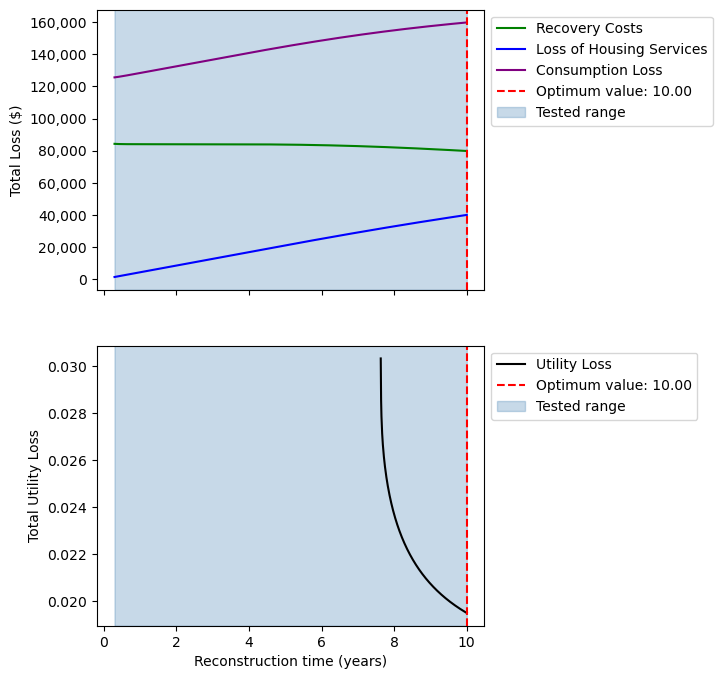

In [4]:
res = household.opt_lambda()
if res["success"]:
    household.plot_opt_lambda(x_type="time")
else:
    print(res["message"])

In [5]:
household.get_losses("trapezoid")

Recovery Costs                        79800.219863
Loss of Housing Services              39956.951711
Loss of Housing Services (Rental)     26637.967808
Labour Income Loss (Public)            9513.559931
Labour Income Loss (Private)           4003.528094
Labour Income Loss                    13517.088025
Consumption Loss                     159912.227407
Utility Loss                              0.019479
Wellbeing Loss                       182648.410940
Asset Loss                            84000.000000
Equity Weighted Loss                  53305.387793
dtype: float64

In [6]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
print(
    f"Achieved recovery in {household.config.simulation.t_max} years: {household.achieved_recovery_percent():.2f} %"
)

Recovery Time: 9.80 years
Achieved recovery in 10.0 years: 95.28 %


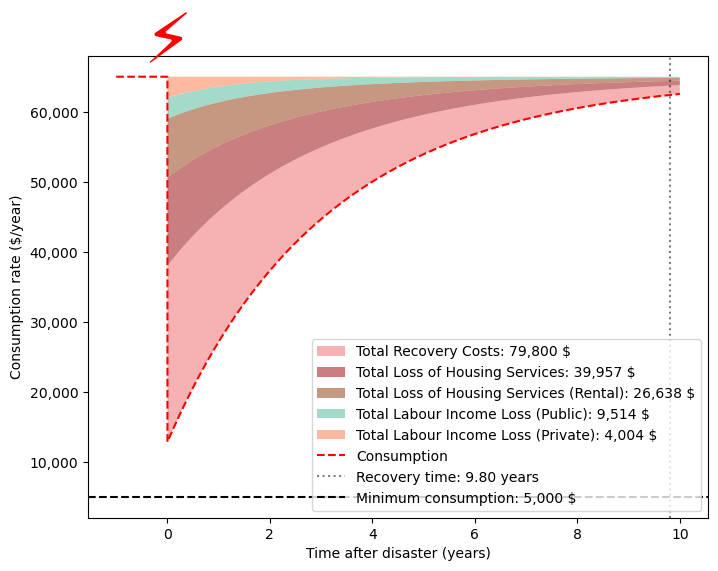

In [7]:
household.plot_consumption()